In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--force-reinstall", "--no-cache-dir",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "torchaudio==2.7.1",
    "transformers==4.52.4",
    "accelerate==1.7.0",
    "datasets==3.6.0",
    "evaluate==0.4.3",
    "tokenizers==0.21.1"
])

0

In [1]:
import sys
import transformers
import accelerate
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers: 4.52.4
Accelerate: 1.7.0
Datasets: 3.6.0
Torch: 2.7.1+cu126
CUDA available: True


In [2]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os,csv,time,random,sys,re,subprocess,importlib.util
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datasets import load_dataset,Dataset
from sklearn.metrics import f1_score,classification_report
from scipy.stats import pearsonr
from transformers import DistilBertTokenizerFast,DistilBertForSequenceClassification,DistilBertModel,TrainingArguments,Trainer,DataCollatorWithPadding,TrainerCallback,EarlyStoppingCallback
from google.colab import drive

# =========================================================
# 2. GOOGLE DRIVE + FILES
# =========================================================
drive.mount("/content/drive")
os.makedirs("/content/drive/MyDrive",exist_ok=True)

LOG_FILE_STEP1="/content/drive/MyDrive/DistilBERT_Hierarchical_Step1.csv"
LOG_FILE_STEP2="/content/drive/MyDrive/DistilBERT_Hierarchical_Step2.csv"
LIME_RESULT_FILE="/content/drive/MyDrive/DistilBERT_Hierarchical_LIME_Results.csv"

for LOG_FILE,STEP_NAME,EPOCHS in [
    (LOG_FILE_STEP1,"STEP 1",3),
    (LOG_FILE_STEP2,"STEP 2",3)
]:
    with open(LOG_FILE,"w",newline="",encoding="utf-8") as f:
        writer=csv.writer(f)
        writer.writerow(["model","distilbert-base-uncased"])
        writer.writerow(["step",STEP_NAME])
        writer.writerow(["learning_rate",2e-5])
        writer.writerow(["train_batch_size",8])
        writer.writerow(["eval_batch_size",8])
        writer.writerow(["epochs",EPOCHS])
        writer.writerow([])

# =========================================================
# 3. SEED + DEVICE
# =========================================================
SEED=42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)

if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))

# =========================================================
# 4. LABELS
# =========================================================
EMOTIONS=["anger","fear","joy","sadness","surprise"]
INTENSITY_COLUMNS=[f"{emotion}_intensity" for emotion in EMOTIONS]
LEVELS=[1,2,3]
LABELS=[f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
label2id={label:i for i,label in enumerate(LABELS)}

# =========================================================
# 5. LOAD DATASET
# =========================================================
train_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="train")
val_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="dev")
test_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="test")

train_df=train_data.to_pandas()
val_df=val_data.to_pandas()
test_df=test_data.to_pandas()

print("Original sizes:")
print({"train":len(train_df),"val":len(val_df),"test":len(test_df)})

# =========================================================
# 6. PREPARE TWO-STEP DATA
# =========================================================
def prepare_two_step_data(df):
    df=df.copy()

    if "disgust" in df.columns:
        df=df.drop(columns=["disgust"])

    for emotion in EMOTIONS:
        df[f"{emotion}_intensity"]=df[emotion].astype(int)

    for emotion in EMOTIONS:
        df[emotion]=(df[f"{emotion}_intensity"]>0).astype(int)

    return df

train_two=prepare_two_step_data(train_df)
val_two=prepare_two_step_data(val_df)
test_two=prepare_two_step_data(test_df)

# =========================================================
# 7. TRUE 70/20/10 SPLIT
# =========================================================
full_df=pd.concat([train_two,val_two,test_two],ignore_index=True)
full_df=full_df[["text"]+EMOTIONS+INTENSITY_COLUMNS]
full_df=full_df.sample(frac=1,random_state=SEED).reset_index(drop=True)

n=len(full_df)
train_end=int(0.7*n)
val_end=int(0.9*n)

train_split=full_df[:train_end].reset_index(drop=True)
val_split=full_df[train_end:val_end].reset_index(drop=True)
test_split=full_df[val_end:].reset_index(drop=True)

print("New split sizes:")
print({"train":len(train_split),"val":len(val_split),"test":len(test_split)})

test_texts_hierarchical=test_split["text"].astype(str).tolist()

# =========================================================
# 8. STEP 1 DATA
# =========================================================
train_step1_df=train_split[["text"]+EMOTIONS].copy()
val_step1_df=val_split[["text"]+EMOTIONS].copy()
test_step1_df=test_split[["text"]+EMOTIONS].copy()

# =========================================================
# 9. STEP 2 DATA
# =========================================================
train_step2_df=train_split[["text"]+INTENSITY_COLUMNS].copy()
val_step2_df=val_split[["text"]+INTENSITY_COLUMNS].copy()
test_step2_df=test_split[["text"]+INTENSITY_COLUMNS].copy()

# =========================================================
# 10. HF DATASETS
# =========================================================
train_step1_ds=Dataset.from_pandas(train_step1_df,preserve_index=False)
val_step1_ds=Dataset.from_pandas(val_step1_df,preserve_index=False)
test_step1_ds=Dataset.from_pandas(test_step1_df,preserve_index=False)

train_step2_ds=Dataset.from_pandas(train_step2_df,preserve_index=False)
val_step2_ds=Dataset.from_pandas(val_step2_df,preserve_index=False)
test_step2_ds=Dataset.from_pandas(test_step2_df,preserve_index=False)

# =========================================================
# 11. TOKENIZER
# =========================================================
tokenizer=DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(examples["text"],truncation=True,max_length=128)

train_step1_ds=train_step1_ds.map(tokenize_function,batched=True)
val_step1_ds=val_step1_ds.map(tokenize_function,batched=True)
test_step1_ds=test_step1_ds.map(tokenize_function,batched=True)

train_step2_ds=train_step2_ds.map(tokenize_function,batched=True)
val_step2_ds=val_step2_ds.map(tokenize_function,batched=True)
test_step2_ds=test_step2_ds.map(tokenize_function,batched=True)

# =========================================================
# 12. ADD LABELS
# =========================================================
def add_step1_labels(example):
    example["labels"]=[float(example[emotion]) for emotion in EMOTIONS]
    return example

def add_step2_labels(example):
    example["labels"]=[int(example[col]) for col in INTENSITY_COLUMNS]
    return example

train_step1_ds=train_step1_ds.map(add_step1_labels)
val_step1_ds=val_step1_ds.map(add_step1_labels)
test_step1_ds=test_step1_ds.map(add_step1_labels)

train_step2_ds=train_step2_ds.map(add_step2_labels)
val_step2_ds=val_step2_ds.map(add_step2_labels)
test_step2_ds=test_step2_ds.map(add_step2_labels)

train_step1_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
val_step1_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
test_step1_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])

train_step2_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
val_step2_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
test_step2_ds.set_format(type="torch",columns=["input_ids","attention_mask","labels"])

# =========================================================
# 13. STEP 1 METRICS
# =========================================================
def compute_metrics_step1(eval_pred):
    logits,labels=eval_pred
    probs=1/(1+np.exp(-logits))
    preds=(probs>=0.5).astype(int)

    f1_macro=f1_score(labels,preds,average="macro",zero_division=0)
    f1_micro=f1_score(labels,preds,average="micro",zero_division=0)

    pearsons=[]

    for i in range(labels.shape[1]):
        if np.std(labels[:,i])==0 or np.std(probs[:,i])==0:
            pearsons.append(0.0)
        else:
            p,_=pearsonr(labels[:,i],probs[:,i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    return {
        "f1_macro":f1_macro,
        "f1_micro":f1_micro,
        "pearson_mean":float(np.mean(pearsons))
    }

# =========================================================
# 14. STEP 1 CALLBACK
# =========================================================
class SaveMetricsCallbackStep1(TrainerCallback):
    def __init__(self,file_path,test_dataset):
        self.file_path=file_path
        self.test_dataset=test_dataset
        self.trainer_ref=None
        self.current_train_loss=None
        self._inside_eval=False

    def on_log(self,args,state,control,logs=None,**kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss=float(logs["loss"])

    def on_evaluate(self,args,state,control,metrics=None,**kwargs):
        if self._inside_eval or metrics is None or "eval_loss" not in metrics:
            return

        self._inside_eval=True

        try:
            epoch=int(round(float(metrics.get("epoch",state.epoch))))
            train_loss=self.current_train_loss if self.current_train_loss is not None else ""

            val_loss=float(metrics.get("eval_loss",0.0))
            val_f1_macro=float(metrics.get("eval_f1_macro",0.0))
            val_f1_micro=float(metrics.get("eval_f1_micro",0.0))
            val_pearson=float(metrics.get("eval_pearson_mean",0.0))

            pred=self.trainer_ref.predict(self.test_dataset,metric_key_prefix="test")

            test_loss=float(pred.metrics.get("test_loss",0.0))
            test_f1_macro=float(pred.metrics.get("test_f1_macro",0.0))
            test_f1_micro=float(pred.metrics.get("test_f1_micro",0.0))
            test_pearson=float(pred.metrics.get("test_pearson_mean",0.0))

            probs=1/(1+np.exp(-pred.predictions))
            pred_labels=(probs>=0.5).astype(int)
            true_labels=pred.label_ids.astype(int)

            report=classification_report(
                true_labels,
                pred_labels,
                target_names=EMOTIONS,
                zero_division=0,
                output_dict=True
            )

            with open(self.file_path,"a",newline="",encoding="utf-8") as f:
                writer=csv.writer(f)

                writer.writerow([])
                writer.writerow([f"EPOCH {epoch}"])

                writer.writerow([
                    "epoch","train_loss","val_loss","test_loss",
                    "val_f1_macro","val_f1_micro","test_f1_macro",
                    "test_f1_micro","val_pearson_mean","test_pearson_mean"
                ])

                writer.writerow([
                    epoch,train_loss,val_loss,test_loss,
                    val_f1_macro,val_f1_micro,test_f1_macro,
                    test_f1_micro,val_pearson,test_pearson
                ])

                writer.writerow([])
                writer.writerow([f"CLASSWISE RESULTS AFTER EPOCH {epoch}"])

                writer.writerow([
                    "class","precision","recall","f1_score",
                    "TP","TN","FN","FP","support"
                ])

                for class_index,class_name in enumerate(EMOTIONS):
                    row=report.get(class_name,{})
                    true_class=true_labels[:,class_index]
                    pred_class=pred_labels[:,class_index]

                    tp=int(np.sum((true_class==1)&(pred_class==1)))
                    tn=int(np.sum((true_class==0)&(pred_class==0)))
                    fn=int(np.sum((true_class==1)&(pred_class==0)))
                    fp=int(np.sum((true_class==0)&(pred_class==1)))

                    writer.writerow([
                        class_name,
                        row.get("precision",""),
                        row.get("recall",""),
                        row.get("f1-score",""),
                        tp,tn,fn,fp,
                        row.get("support","")
                    ])

            print(f"Step 1 epoch {epoch} results saved.")

        finally:
            self._inside_eval=False

# =========================================================
# 15. STEP 1 MODEL
# =========================================================
model_step1=DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(EMOTIONS),
    problem_type="multi_label_classification"
)

# =========================================================
# 16. STEP 1 TRAINING ARGS
# =========================================================
training_args_step1=TrainingArguments(
    output_dir="/content/distilbert_step1_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================================================
# 17. STEP 1 TRAINER
# =========================================================
callback_step1=SaveMetricsCallbackStep1(
    file_path=LOG_FILE_STEP1,
    test_dataset=test_step1_ds
)

trainer_step1=Trainer(
    model=model_step1,
    args=training_args_step1,
    train_dataset=train_step1_ds,
    eval_dataset=val_step1_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step1,
    callbacks=[callback_step1]
)

callback_step1.trainer_ref=trainer_step1

# =========================================================
# 18. TRAIN STEP 1
# =========================================================
print("\nStarting Step 1: Emotion Detection")

start1=time.time()
trainer_step1.train()
end1=time.time()

print(f"Step 1 training time: {end1-start1:.1f} seconds")
print("Step 1 result file:",LOG_FILE_STEP1)
print("Step 1 best checkpoint:",trainer_step1.state.best_model_checkpoint)

# =========================================================
# 19. STEP 2 MODEL
# =========================================================
class DistilBertStep2IntensityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.distilbert=DistilBertModel.from_pretrained("distilbert-base-uncased")
        hidden_size=self.distilbert.config.dim
        self.dropout=nn.Dropout(0.1)
        self.classifier=nn.Linear(hidden_size,len(EMOTIONS)*4)

    def forward(self,input_ids=None,attention_mask=None,labels=None):
        outputs=self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output=outputs.last_hidden_state[:,0,:]
        cls_output=self.dropout(cls_output)
        logits=self.classifier(cls_output)
        logits=logits.view(-1,len(EMOTIONS),4)

        loss=None

        if labels is not None:
            loss_fct=nn.CrossEntropyLoss()
            loss=loss_fct(
                logits.view(-1,4),
                labels.long().view(-1)
            )

        return {
            "loss":loss,
            "logits":logits
        }

# =========================================================
# 20. STEP 2 METRICS
# =========================================================
def compute_metrics_step2(eval_pred):
    logits,labels=eval_pred
    preds=np.argmax(logits,axis=-1)

    true_flat=labels.reshape(-1)
    pred_flat=preds.reshape(-1)

    f1_macro=f1_score(
        true_flat,
        pred_flat,
        average="macro",
        zero_division=0
    )

    f1_micro=f1_score(
        true_flat,
        pred_flat,
        average="micro",
        zero_division=0
    )

    if np.std(true_flat)==0 or np.std(pred_flat)==0:
        pearson_mean=0.0
    else:
        pearson_mean,_=pearsonr(true_flat,pred_flat)
        pearson_mean=0.0 if np.isnan(pearson_mean) else float(pearson_mean)

    return {
        "f1_macro":f1_macro,
        "f1_micro":f1_micro,
        "pearson_mean":pearson_mean
    }

# =========================================================
# 21. STEP 2 CALLBACK
# =========================================================
class SaveMetricsCallbackStep2(TrainerCallback):
    def __init__(self,file_path,step1_trainer,test_step1_dataset,test_step2_dataset):
        self.file_path=file_path
        self.step1_trainer=step1_trainer
        self.test_step1_dataset=test_step1_dataset
        self.test_step2_dataset=test_step2_dataset
        self.trainer_ref=None
        self.current_train_loss=None
        self._inside_eval=False

    def on_log(self,args,state,control,logs=None,**kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss=float(logs["loss"])

    def make_final_hierarchical_predictions(self):
        pred_step1=self.step1_trainer.predict(
            self.test_step1_dataset,
            metric_key_prefix="step1_test"
        )

        probs_step1=1/(1+np.exp(-pred_step1.predictions))
        pred_emotions=(probs_step1>=0.5).astype(int)

        pred_step2=self.trainer_ref.predict(
            self.test_step2_dataset,
            metric_key_prefix="test"
        )

        logits_step2=pred_step2.predictions
        true_intensities=pred_step2.label_ids.astype(int)
        test_loss=float(pred_step2.metrics.get("test_loss",0.0))

        probs_step2=torch.softmax(
            torch.tensor(logits_step2),
            dim=-1
        ).numpy()

        pred_intensities=np.argmax(probs_step2,axis=-1)
        final_pred_intensities=pred_intensities*pred_emotions

        true_binary_15=np.zeros(
            (true_intensities.shape[0],len(LABELS)),
            dtype=int
        )

        pred_binary_15=np.zeros(
            (true_intensities.shape[0],len(LABELS)),
            dtype=int
        )

        prob_binary_15=np.zeros(
            (true_intensities.shape[0],len(LABELS)),
            dtype=float
        )

        for emotion_index,emotion in enumerate(EMOTIONS):
            for level in LEVELS:
                class_index=emotion_index*3+(level-1)

                true_binary_15[:,class_index]=(
                    true_intensities[:,emotion_index]==level
                ).astype(int)

                pred_binary_15[:,class_index]=(
                    final_pred_intensities[:,emotion_index]==level
                ).astype(int)

                prob_binary_15[:,class_index]=(
                    probs_step1[:,emotion_index]*
                    probs_step2[:,emotion_index,level]
                )

        return true_binary_15,pred_binary_15,prob_binary_15,test_loss

    def on_evaluate(self,args,state,control,metrics=None,**kwargs):
        if self._inside_eval or metrics is None or "eval_loss" not in metrics:
            return

        self._inside_eval=True

        try:
            epoch=int(round(float(metrics.get("epoch",state.epoch))))
            train_loss=self.current_train_loss if self.current_train_loss is not None else ""

            val_loss=float(metrics.get("eval_loss",0.0))
            val_f1_macro=float(metrics.get("eval_f1_macro",0.0))
            val_f1_micro=float(metrics.get("eval_f1_micro",0.0))
            val_pearson=float(metrics.get("eval_pearson_mean",0.0))

            true_binary_15,pred_binary_15,prob_binary_15,test_loss=self.make_final_hierarchical_predictions()

            test_f1_macro=f1_score(
                true_binary_15,
                pred_binary_15,
                average="macro",
                zero_division=0
            )

            test_f1_micro=f1_score(
                true_binary_15,
                pred_binary_15,
                average="micro",
                zero_division=0
            )

            pearsons=[]

            for class_index in range(len(LABELS)):
                true_column=true_binary_15[:,class_index]
                probability_column=prob_binary_15[:,class_index]

                if np.std(true_column)==0 or np.std(probability_column)==0:
                    pearsons.append(0.0)
                else:
                    p,_=pearsonr(true_column,probability_column)
                    pearsons.append(0.0 if np.isnan(p) else float(p))

            test_pearson=float(np.mean(pearsons))

            report=classification_report(
                true_binary_15,
                pred_binary_15,
                target_names=LABELS,
                zero_division=0,
                output_dict=True
            )

            with open(self.file_path,"a",newline="",encoding="utf-8") as f:
                writer=csv.writer(f)

                writer.writerow([])
                writer.writerow([f"EPOCH {epoch}"])

                writer.writerow([
                    "epoch","train_loss","val_loss","test_loss",
                    "val_f1_macro","val_f1_micro","test_f1_macro",
                    "test_f1_micro","val_pearson_mean","test_pearson_mean"
                ])

                writer.writerow([
                    epoch,train_loss,val_loss,test_loss,
                    val_f1_macro,val_f1_micro,test_f1_macro,
                    test_f1_micro,val_pearson,test_pearson
                ])

                writer.writerow([])
                writer.writerow([f"CLASSWISE RESULTS AFTER EPOCH {epoch}"])

                writer.writerow([
                    "class","precision","recall","f1_score",
                    "TP","TN","FN","FP","support"
                ])

                for class_index,class_name in enumerate(LABELS):
                    row=report.get(class_name,{})
                    true_class=true_binary_15[:,class_index]
                    pred_class=pred_binary_15[:,class_index]

                    tp=int(np.sum((true_class==1)&(pred_class==1)))
                    tn=int(np.sum((true_class==0)&(pred_class==0)))
                    fn=int(np.sum((true_class==1)&(pred_class==0)))
                    fp=int(np.sum((true_class==0)&(pred_class==1)))

                    writer.writerow([
                        class_name,
                        row.get("precision",""),
                        row.get("recall",""),
                        row.get("f1-score",""),
                        tp,tn,fn,fp,
                        row.get("support","")
                    ])

            print(f"Step 2 epoch {epoch} hierarchical results saved.")

        finally:
            self._inside_eval=False

# =========================================================
# 22. STEP 2 MODEL INSTANCE
# =========================================================
model_step2=DistilBertStep2IntensityModel()

# =========================================================
# 23. STEP 2 TRAINING ARGS
# =========================================================
training_args_step2=TrainingArguments(
    output_dir="/content/distilbert_step2_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================================================
# 24. STEP 2 TRAINER
# =========================================================
callback_step2=SaveMetricsCallbackStep2(
    file_path=LOG_FILE_STEP2,
    step1_trainer=trainer_step1,
    test_step1_dataset=test_step1_ds,
    test_step2_dataset=test_step2_ds
)

trainer_step2=Trainer(
    model=model_step2,
    args=training_args_step2,
    train_dataset=train_step2_ds,
    eval_dataset=val_step2_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics_step2,
    callbacks=[
        callback_step2,
        EarlyStoppingCallback(
            early_stopping_patience=1,
            early_stopping_threshold=0.0
        )
    ]
)

callback_step2.trainer_ref=trainer_step2

# =========================================================
# 25. TRAIN STEP 2
# =========================================================
print("\nStarting Step 2: Intensity Classification")

start2=time.time()
trainer_step2.train()
end2=time.time()

print(f"Step 2 training time: {end2-start2:.1f} seconds")
print("Step 2 result file:",LOG_FILE_STEP2)
print("Step 2 best checkpoint:",trainer_step2.state.best_model_checkpoint)

# =========================================================
# 26. FINAL HIERARCHICAL PREDICTIONS
# =========================================================
pred_step1=trainer_step1.predict(test_step1_ds)
step1_probs=1/(1+np.exp(-pred_step1.predictions))
pred_emotions=(step1_probs>=0.5).astype(int)

pred_step2=trainer_step2.predict(test_step2_ds)
step2_logits=pred_step2.predictions
true_intensities=pred_step2.label_ids.astype(int)

step2_probs=torch.softmax(
    torch.tensor(step2_logits),
    dim=-1
).numpy()

pred_intensities=np.argmax(step2_probs,axis=-1)
final_pred_intensities=pred_intensities*pred_emotions

true_binary_15=np.zeros((len(test_split),len(LABELS)),dtype=int)
pred_binary_15=np.zeros((len(test_split),len(LABELS)),dtype=int)
prob_binary_15=np.zeros((len(test_split),len(LABELS)),dtype=float)

for emotion_index,emotion in enumerate(EMOTIONS):
    for level in LEVELS:
        class_index=emotion_index*3+(level-1)

        true_binary_15[:,class_index]=(
            true_intensities[:,emotion_index]==level
        ).astype(int)

        pred_binary_15[:,class_index]=(
            final_pred_intensities[:,emotion_index]==level
        ).astype(int)

        prob_binary_15[:,class_index]=(
            step1_probs[:,emotion_index]*
            step2_probs[:,emotion_index,level]
        )

final_report=classification_report(
    true_binary_15,
    pred_binary_15,
    target_names=LABELS,
    zero_division=0,
    output_dict=True
)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Original sizes:
{'train': 2763, 'val': 115, 'test': 2765}
New split sizes:
{'train': 3950, 'val': 1128, 'test': 565}


Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

...

Step 1 epoch 1 results saved.
Step 1 epoch 2 results saved.
Step 1 epoch 3 results saved.
Step 1 training time: 141.6 seconds
Step 1 result file: /content/drive/MyDrive/DistilBERT_Hierarchical_Step1.csv
Step 1 best checkpoint: /content/distilbert_step1_output/checkpoint-1482

Starting Step 2: Intensity Classification


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson Mean
1,0.729100,0.657477,0.411600,0.731738,0.594774
2,0.558400,0.613842,0.514041,0.748936,0.668599
3,0.472600,0.607108,0.529383,0.754433,0.685943


Step 2 epoch 1 hierarchical results saved.


Step 2 epoch 2 hierarchical results saved.


Step 2 epoch 3 hierarchical results saved.
Step 2 training time: 149.8 seconds
Step 2 result file: /content/drive/MyDrive/DistilBERT_Hierarchical_Step2.csv
Step 2 best checkpoint: /content/distilbert_step2_output/checkpoint-1482



DISTILBERT HIERARCHICAL AGGREGATED LIME ANALYSIS

----------------------------------------------------------------------
[1/15] anger_1
True class sentences: 36
Predicted class sentences: 16
anger_1 true class sentences: 20/36
anger_1 true class sentences: 36/36
anger_1 class predictions: 16/16

----------------------------------------------------------------------
[2/15] anger_2
True class sentences: 15
Predicted class sentences: 4
anger_2 true class sentences: 15/15
anger_2 class predictions: 4/4

----------------------------------------------------------------------
[3/15] anger_3
True class sentences: 9
Predicted class sentences: 0
anger_3 true class sentences: 9/9

----------------------------------------------------------------------
[4/15] fear_1
True class sentences: 159
Predicted class sentences: 190
fear_1 true class sentences: 20/159
fear_1 true class sentences: 40/159
fear_1 true class sentences: 60/159
fear_1 true class sentences: 80/159
fear_1 true class sentences: 100/1

,class,recall,precision,fnr,TP,TN,FN,FP,support,true_class_lime_words,predicted_class_lime_words
0,anger_1,0.1389,0.3125,0.8611,5,518,31,11,36,annoyed (0.2812); messed (0.2795); objected (0...,hell (0.5373); harassing (0.3916); annoyed (0....
1,anger_2,0.1333,0.5000,0.8667,2,548,13,2,15,harassing (0.3647); asshole (0.3610); hell (0....,pissed (0.3890); asshole (0.3621); rage (0.347...
2,anger_3,0.0000,0.0000,1.0000,0,556,9,0,9,rage (0.1579); pissed (0.1417); fucking (0.129...,NO CLASS PREDICTIONS
3,fear_1,0.5031,0.4211,0.4969,80,296,79,110,159,hurt (1.7770); my (1.5365); i (1.3966); weird ...,my (2.2798); i (2.2648); to (1.8274); hurt (1....
4,fear_2,0.3737,0.4111,0.6263,37,413,62,53,99,i (1.2539); to (0.8056); pain (0.6520); and (0...,blood (1.2660); to (0.9214); head (0.8733); i ...
5,fear_3,0.3600,0.7200,0.6400,18,508,32,7,50,freaked (1.9313); danger (0.9269); terrified (...,freaked (2.3809); screaming (1.0910); danger (...
6,joy_1,0.3846,0.4930,0.6154,35,438,56,36,91,my (1.8043); i (1.4489); a (0.5713); the (0.52...,my (1.9207); i (1.5888); nice (0.7915); funny ...
7,joy_2,0.1935,0.2727,0.8065,6,518,25,16,31,lovely (0.3939); smile (0.3667); fun (0.3584);...,awesome (1.2559); smile (1.0594); love (0.6160...
8,joy_3,0.0000,0.0000,1.0000,0,553,12,0,12,awesome (0.6668); love (0.2080); happiness (0....,NO CLASS PREDICTIONS
9,sadness_1,0.3838,0.3918,0.6162,38,407,61,59,99,my (1.2592); hurt (1.0625); upset (0.9048); an...,my (1.9326); aching (1.5179); and (1.1616); bl...



Saved:
/content/drive/MyDrive/DistilBERT_Hierarchical_LIME_Results.csv


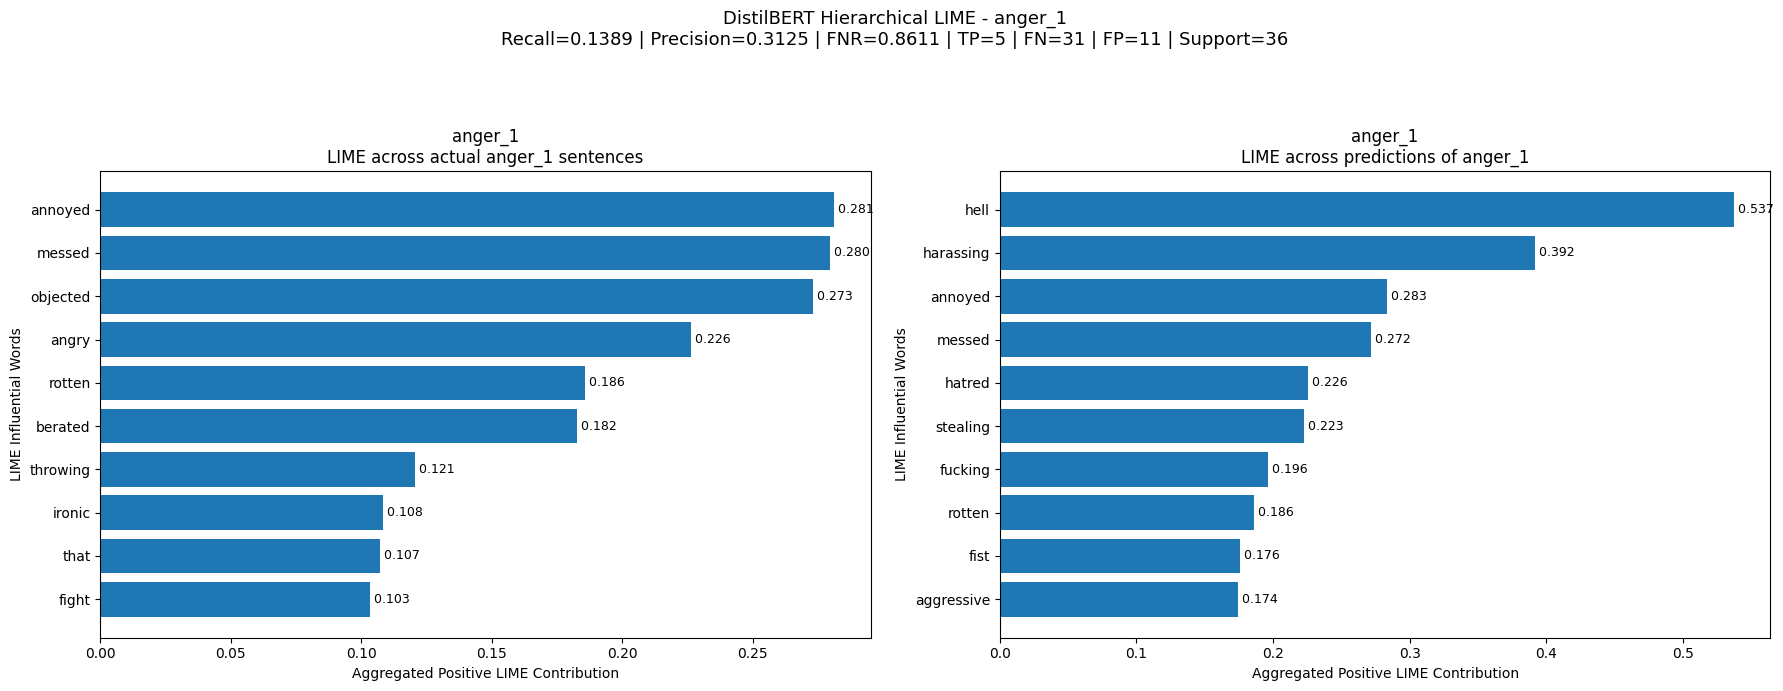

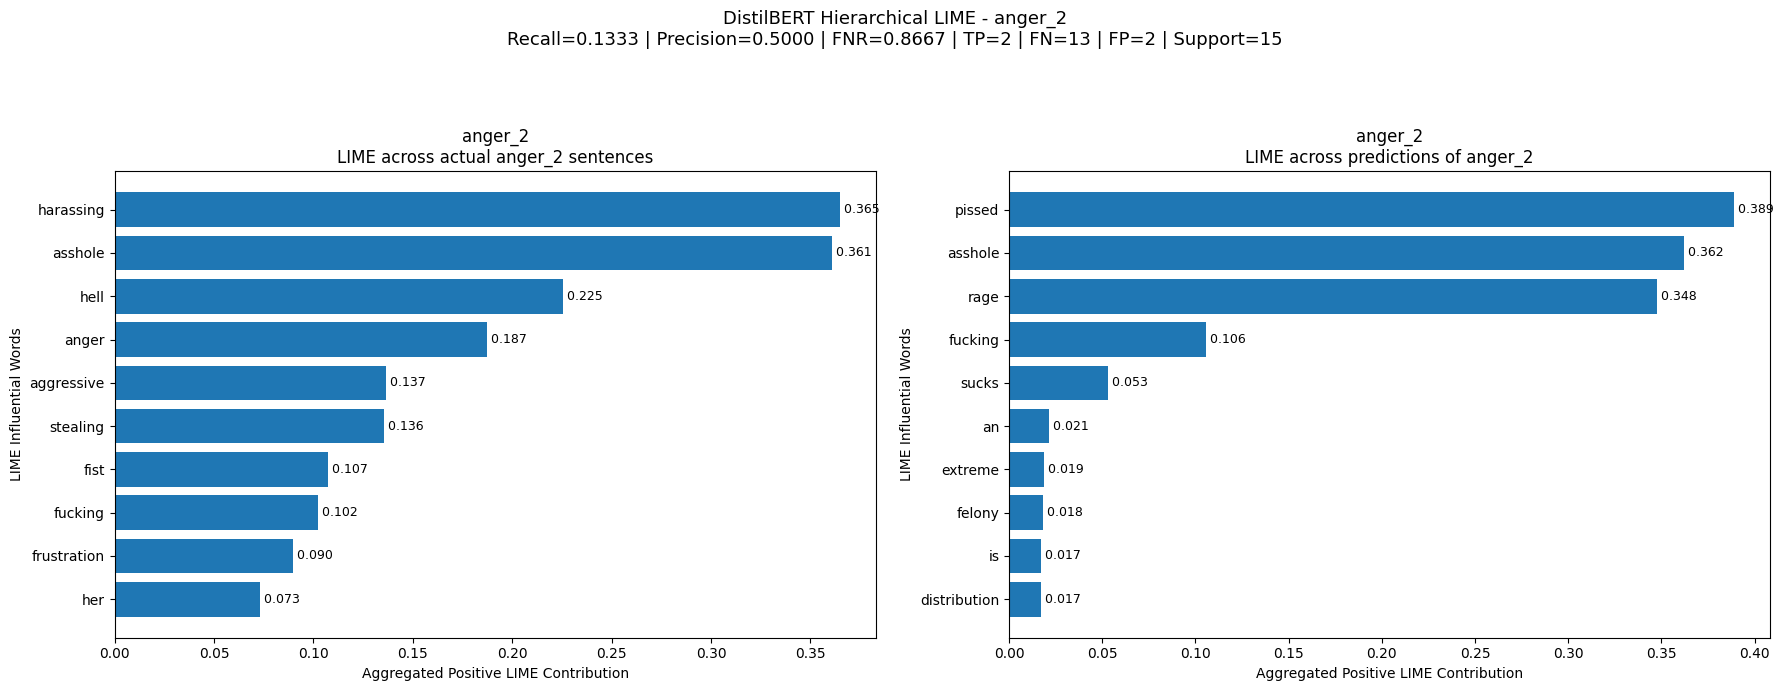

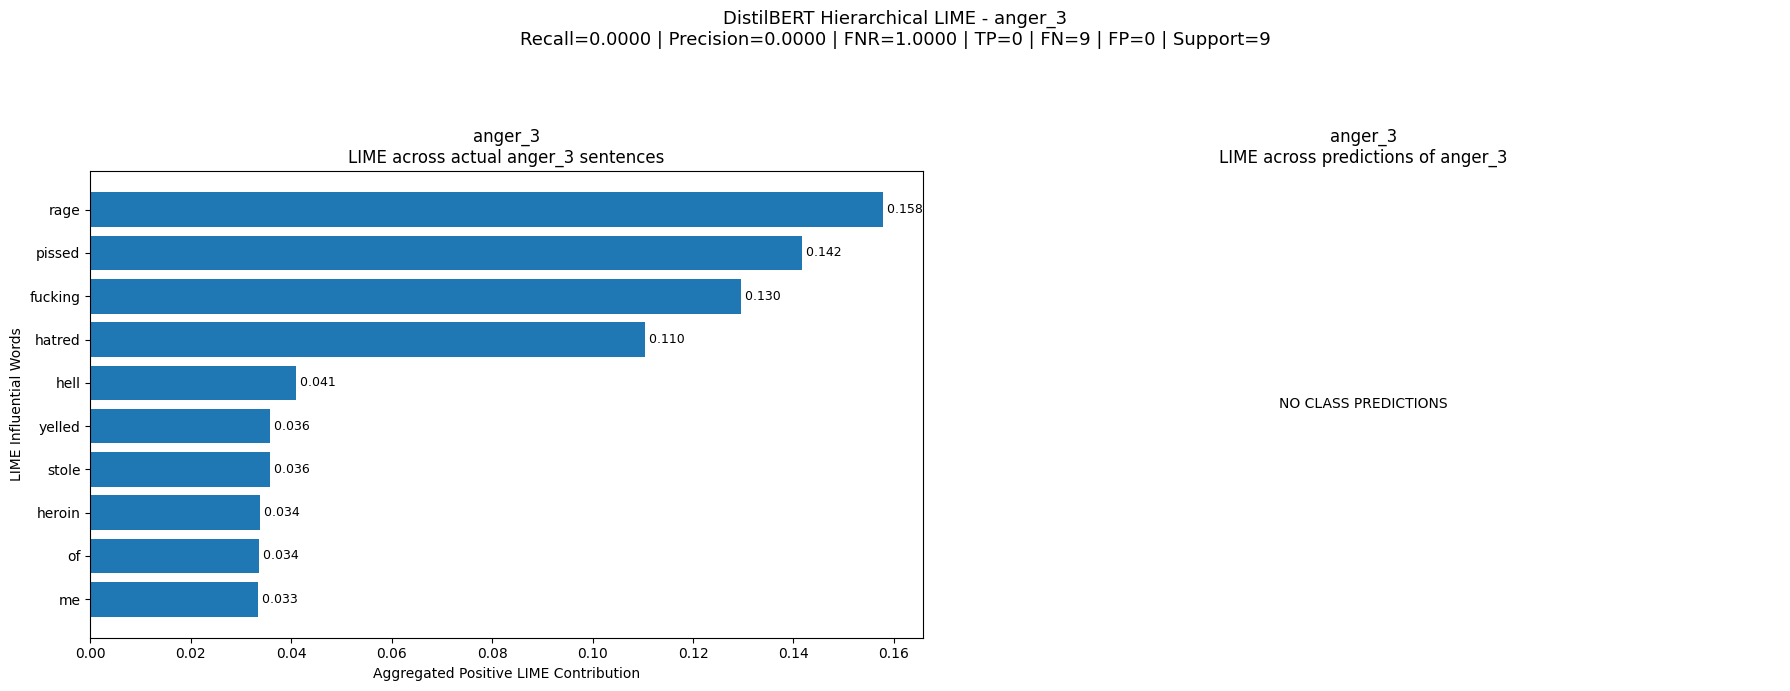

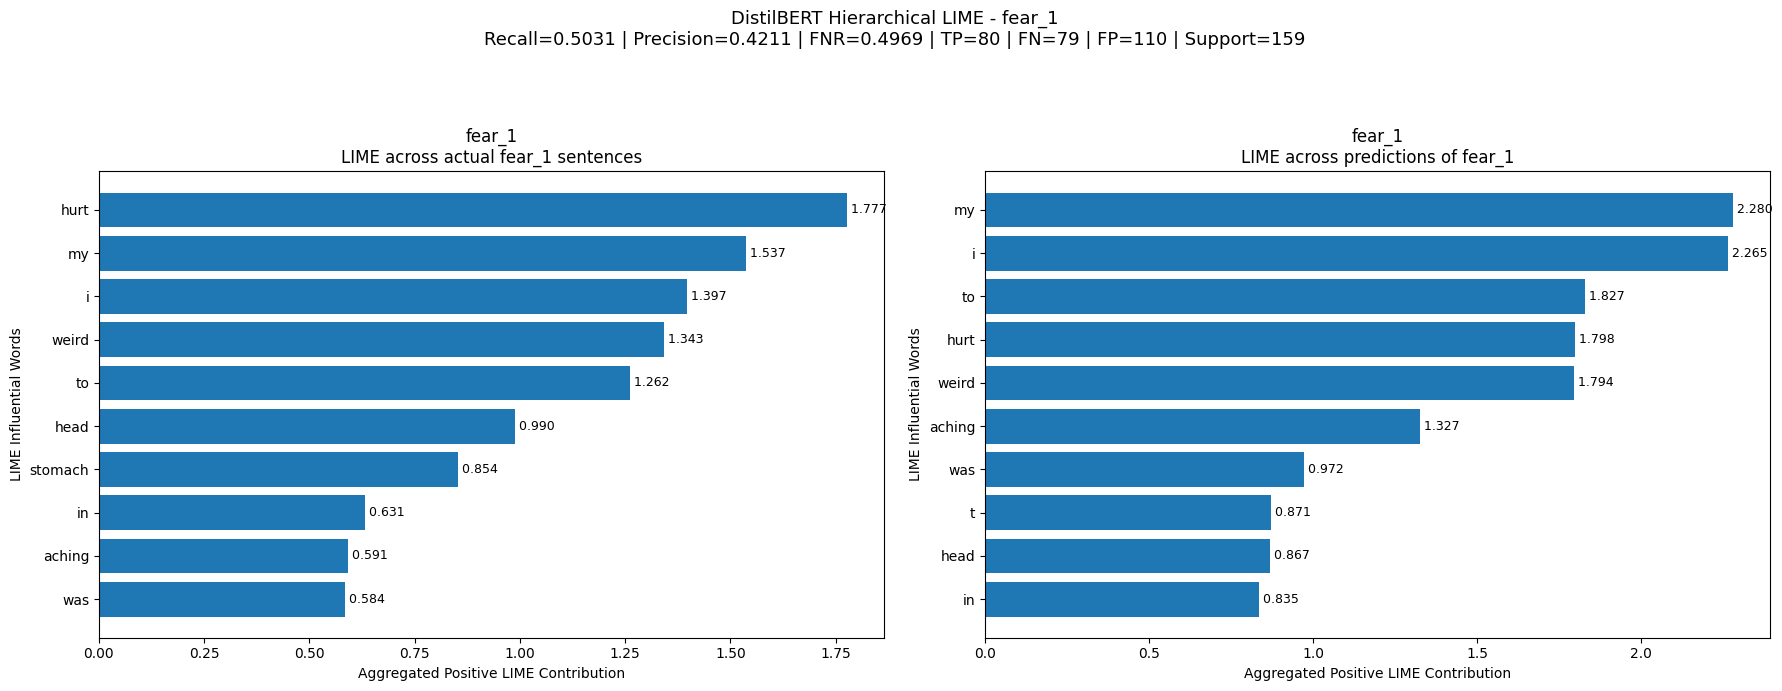

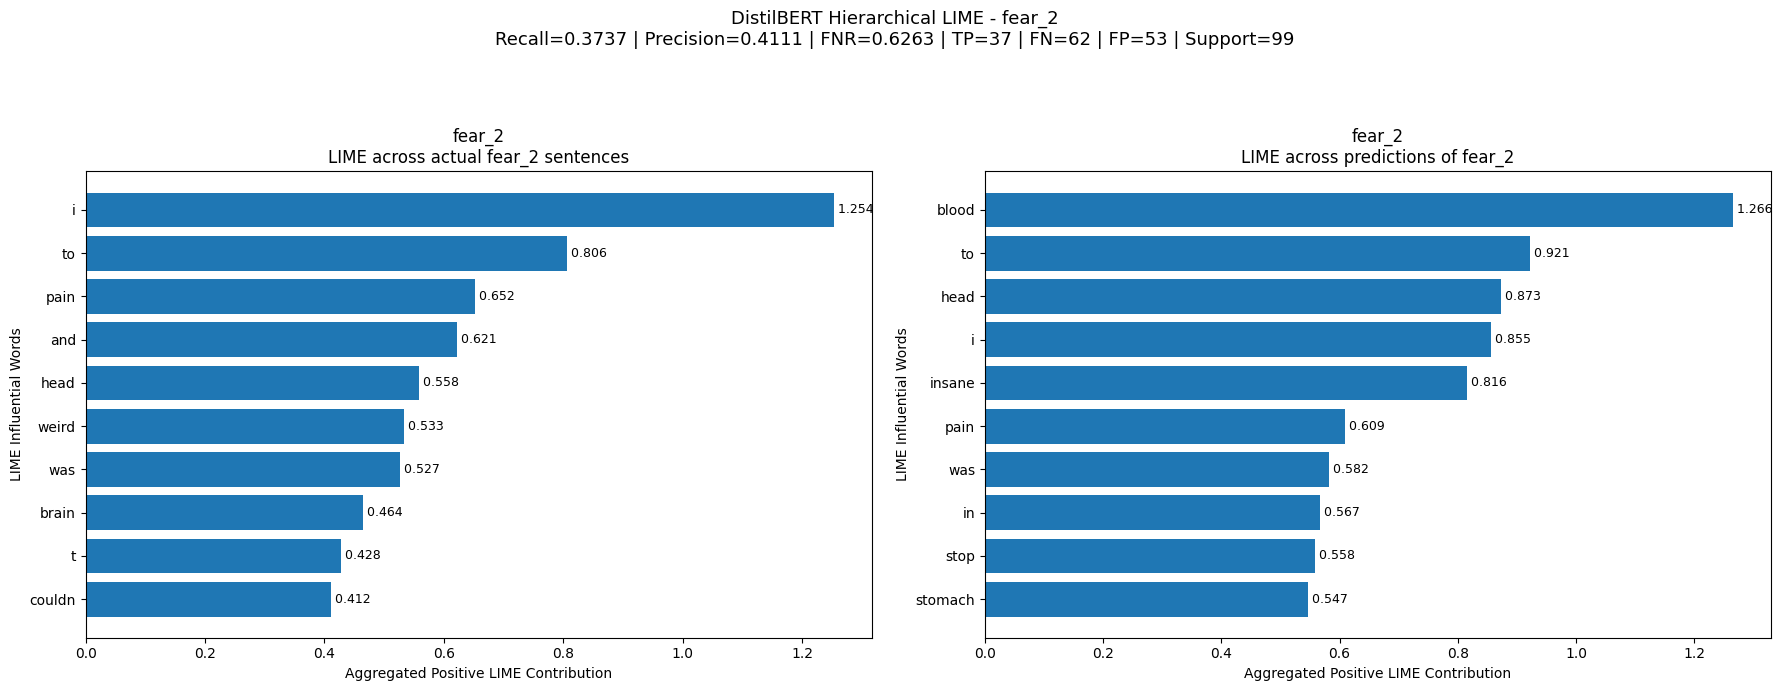

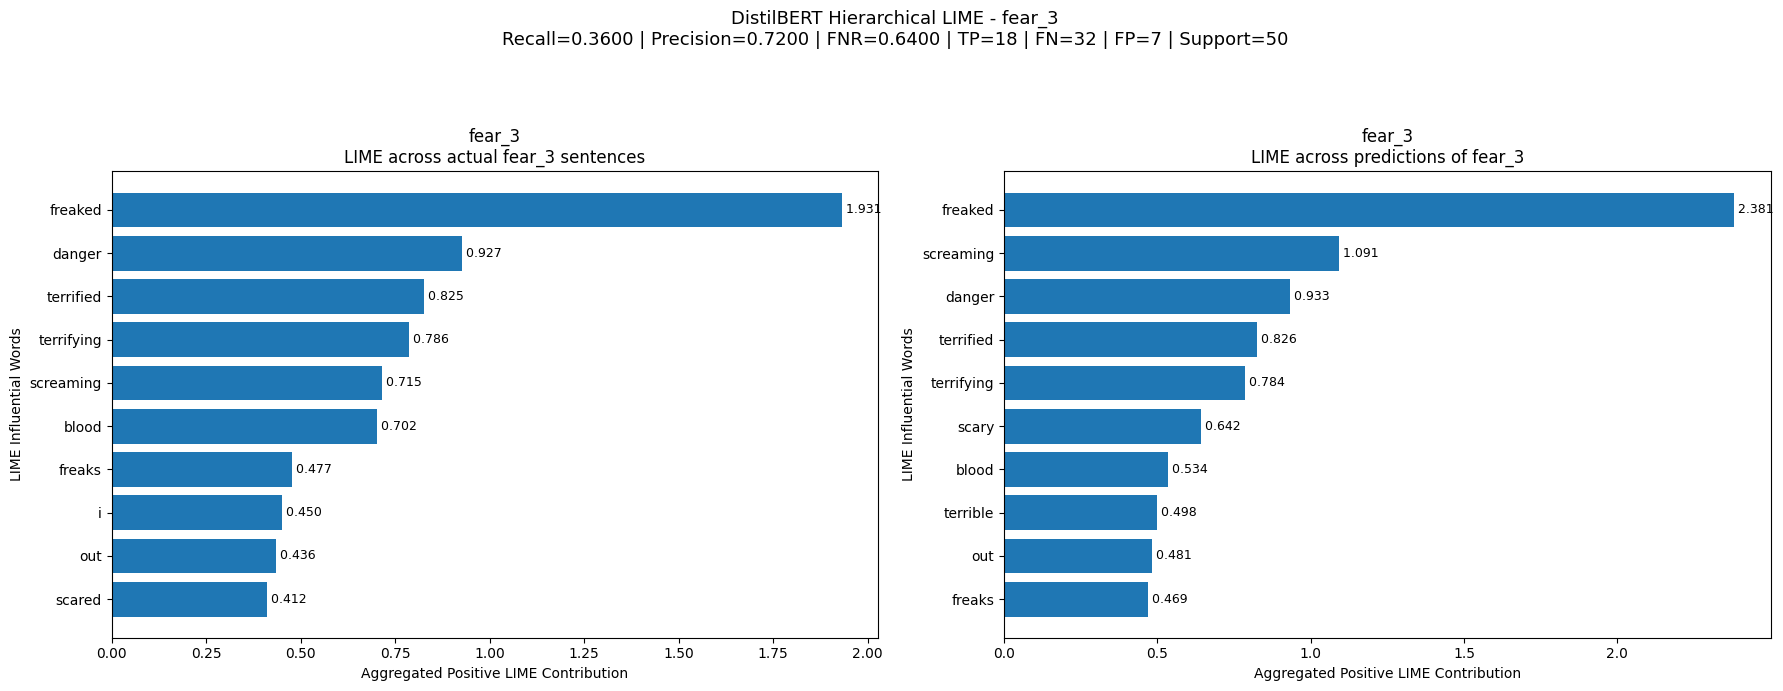

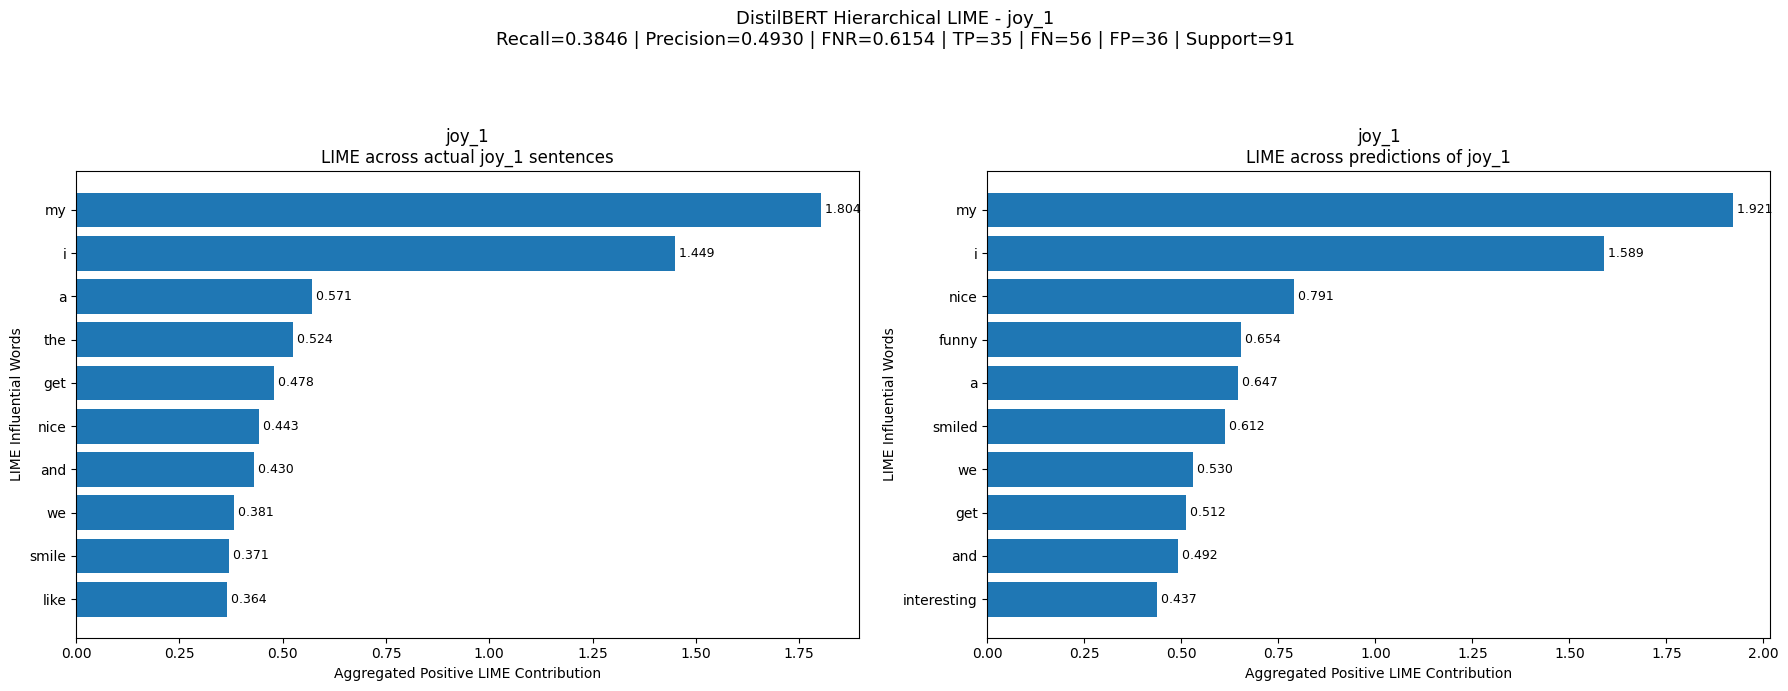

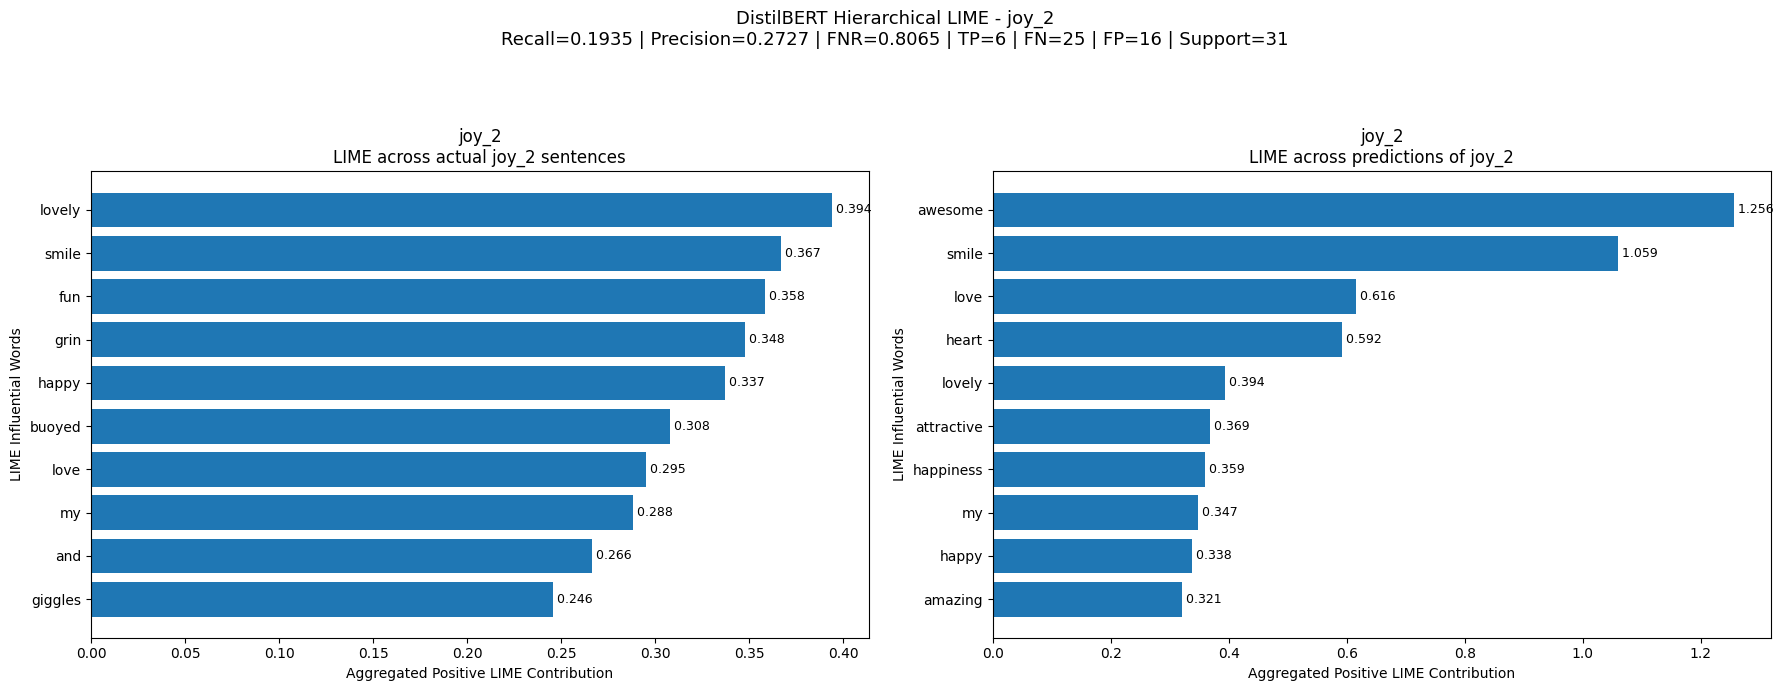

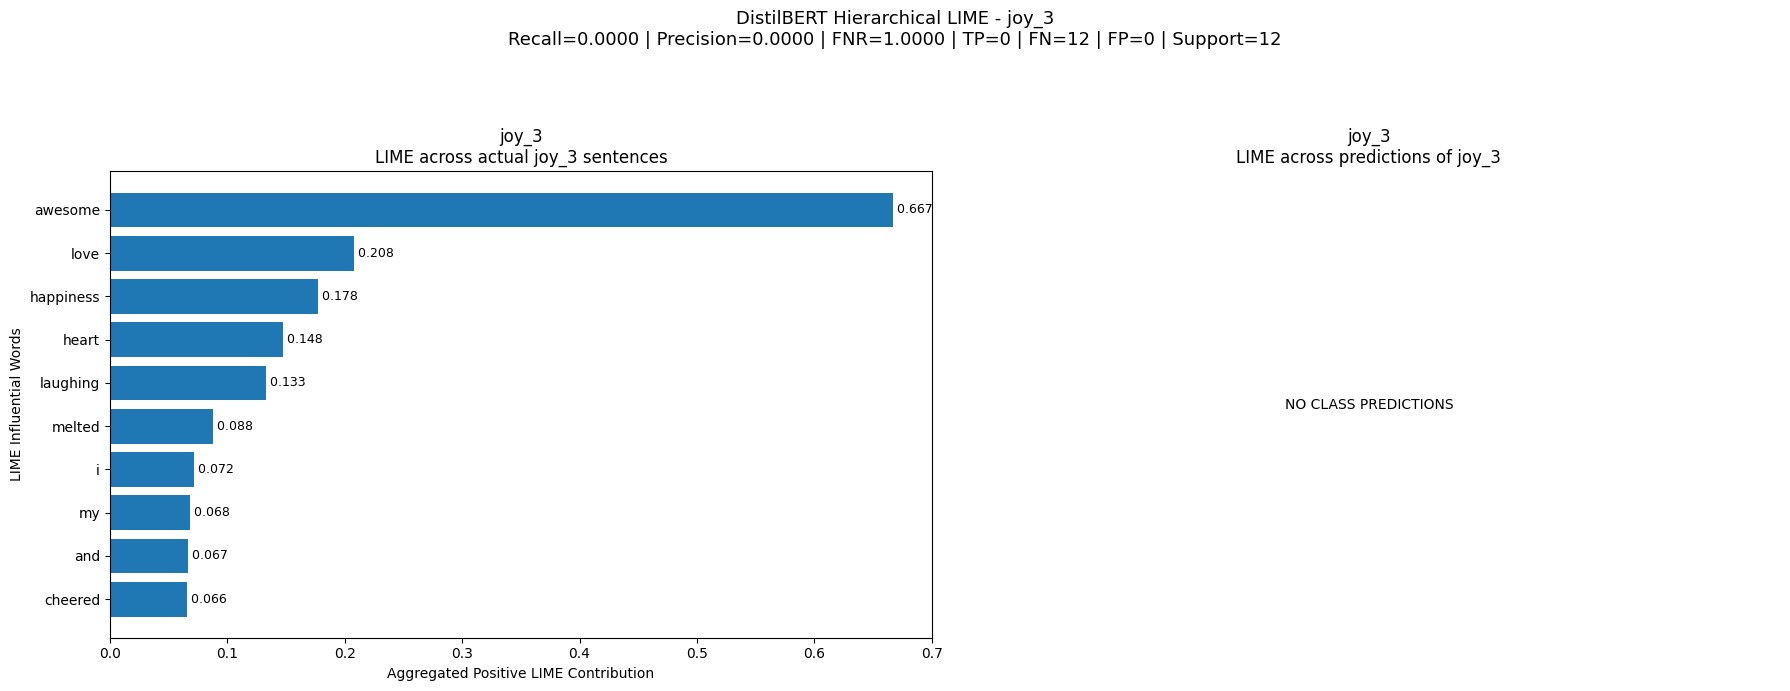

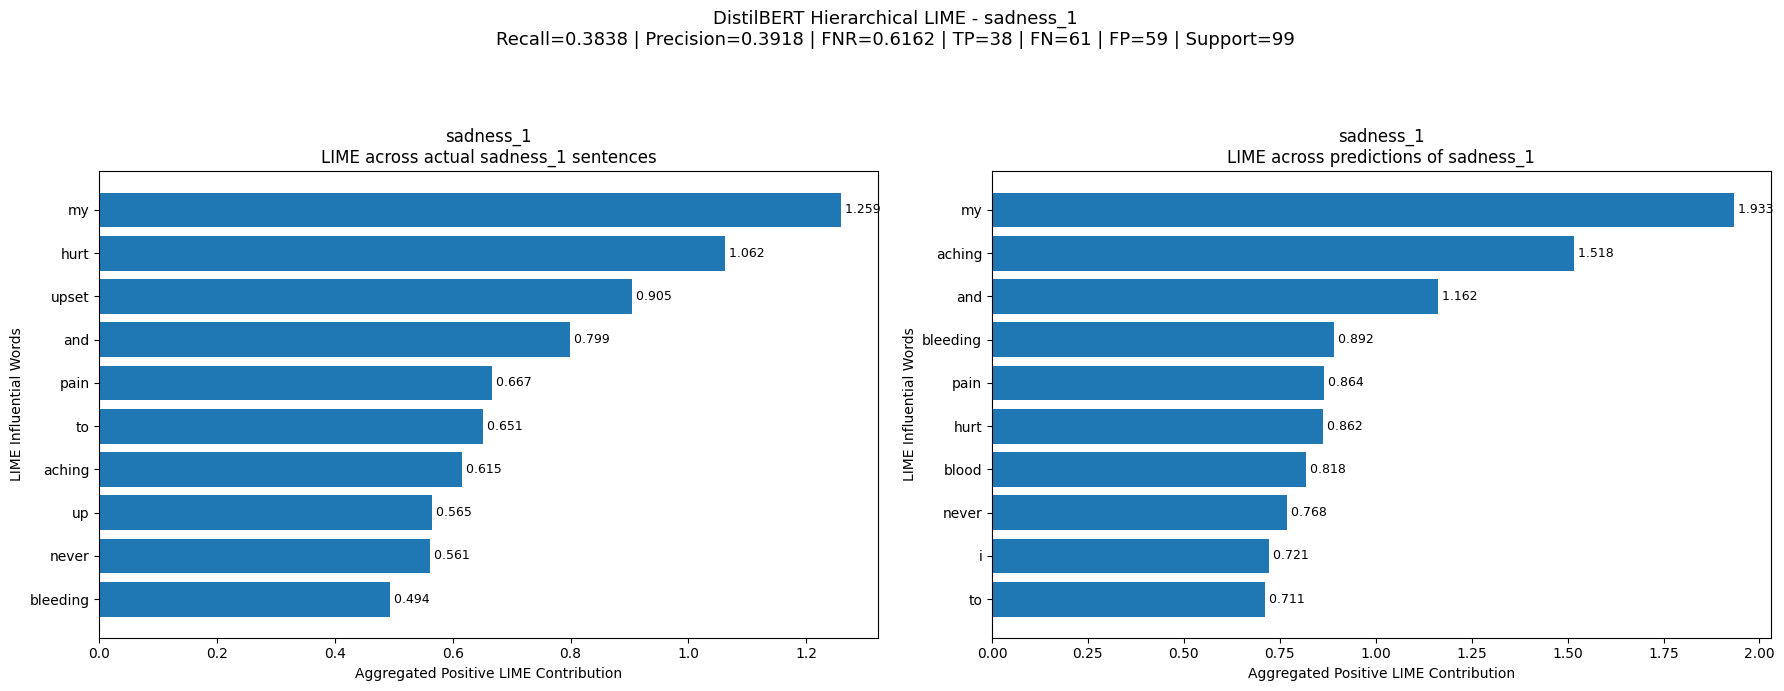

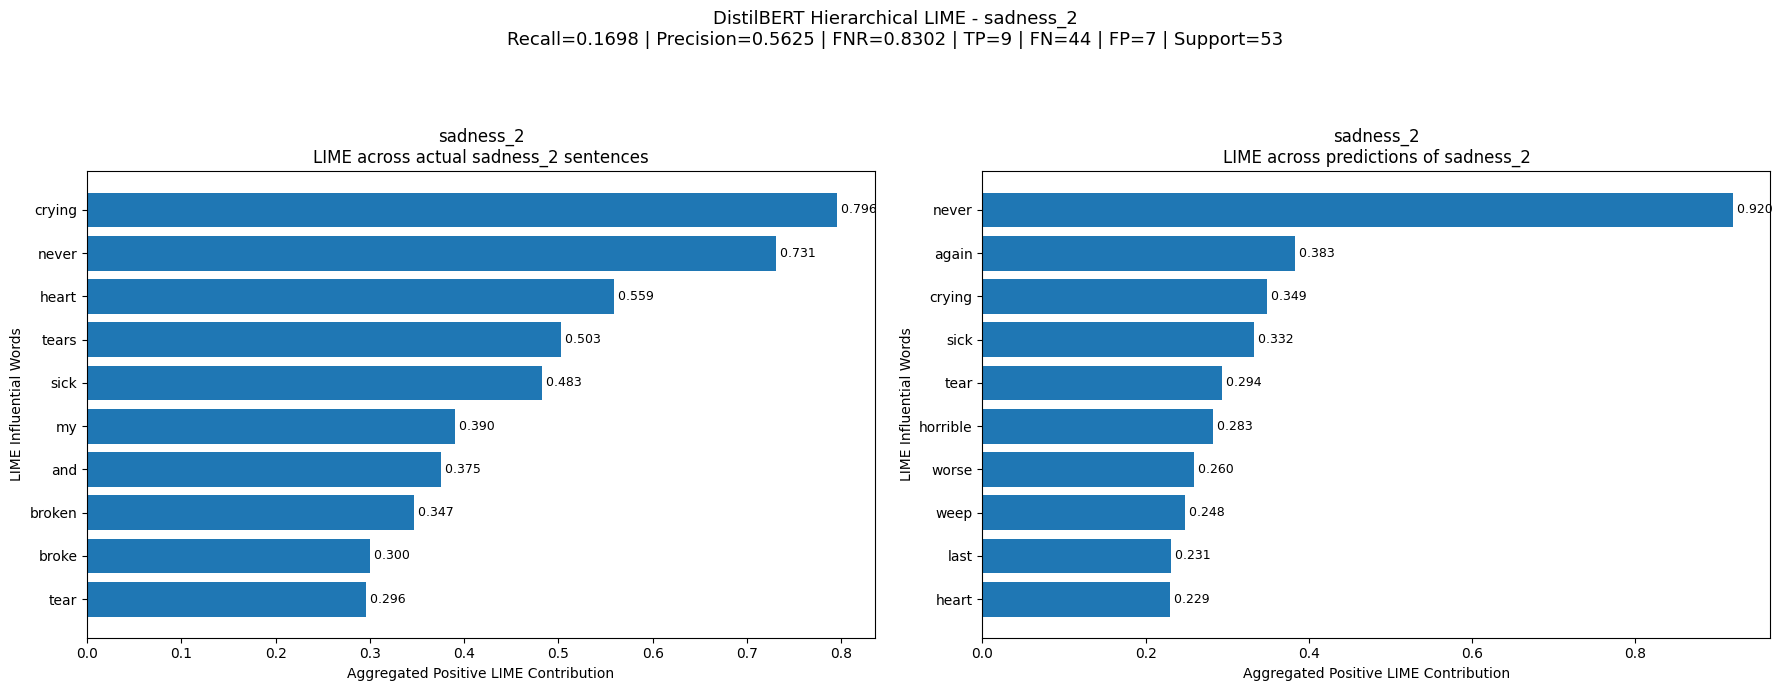

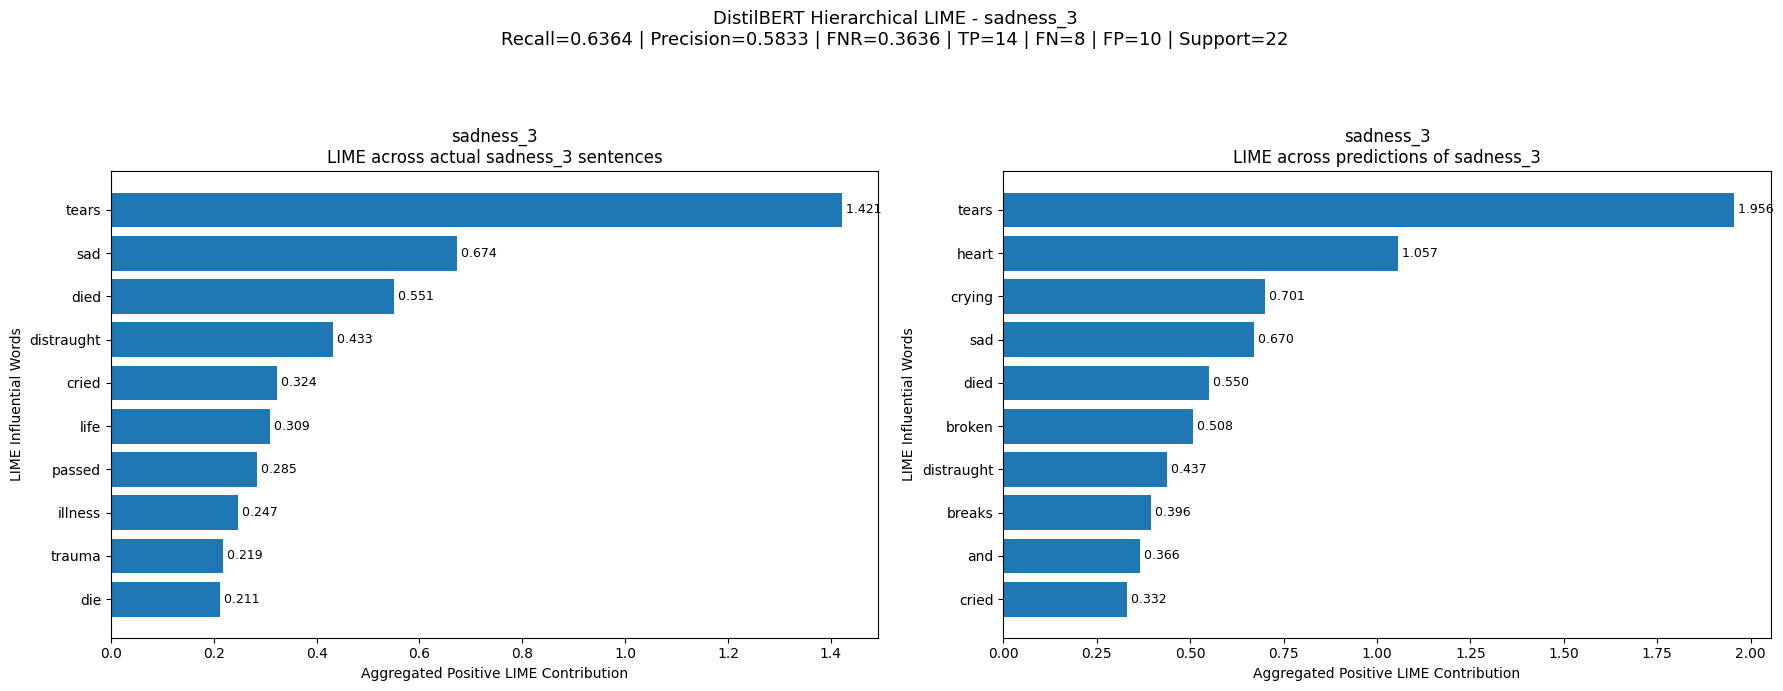

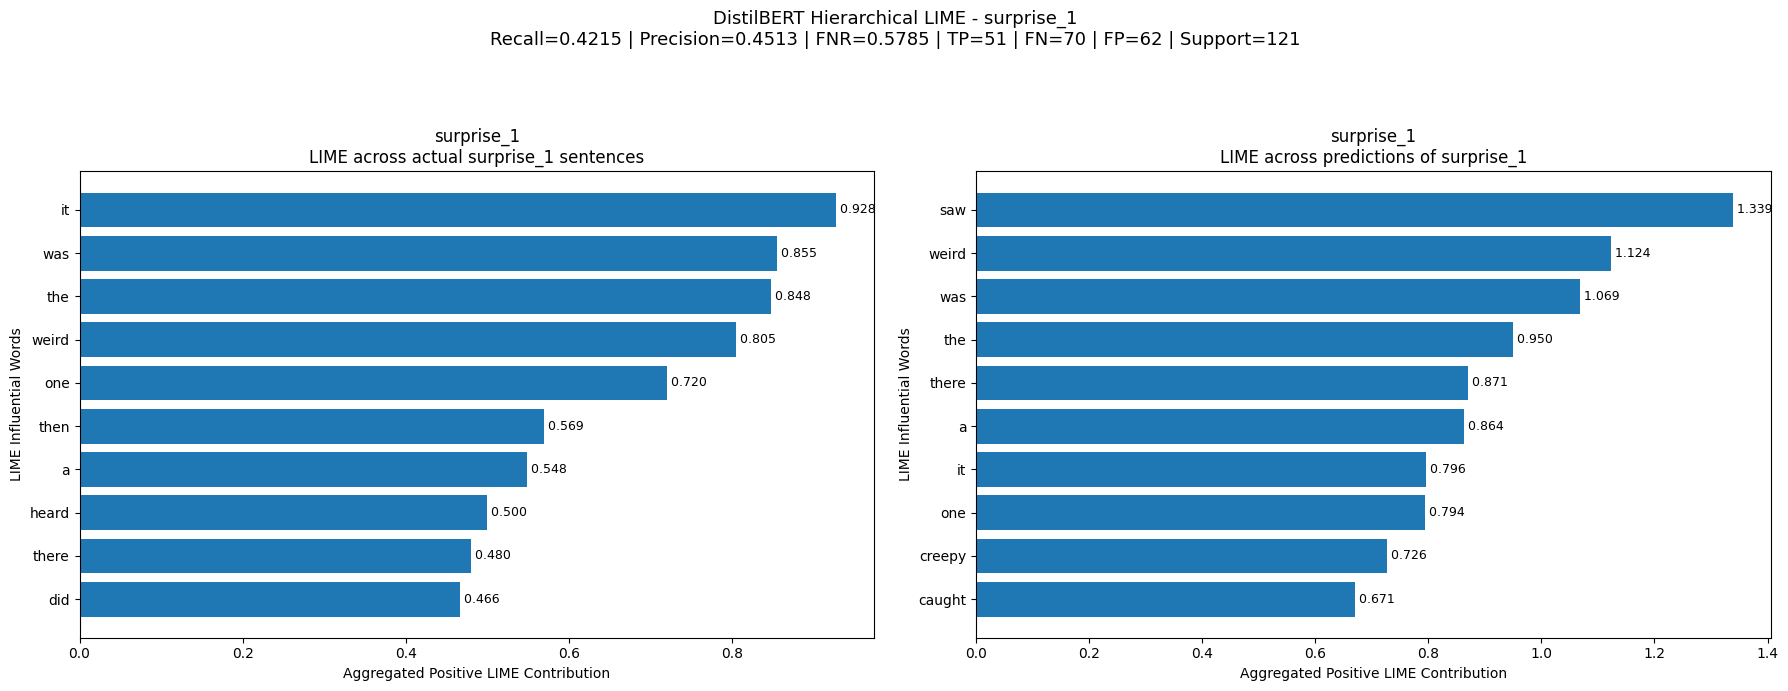

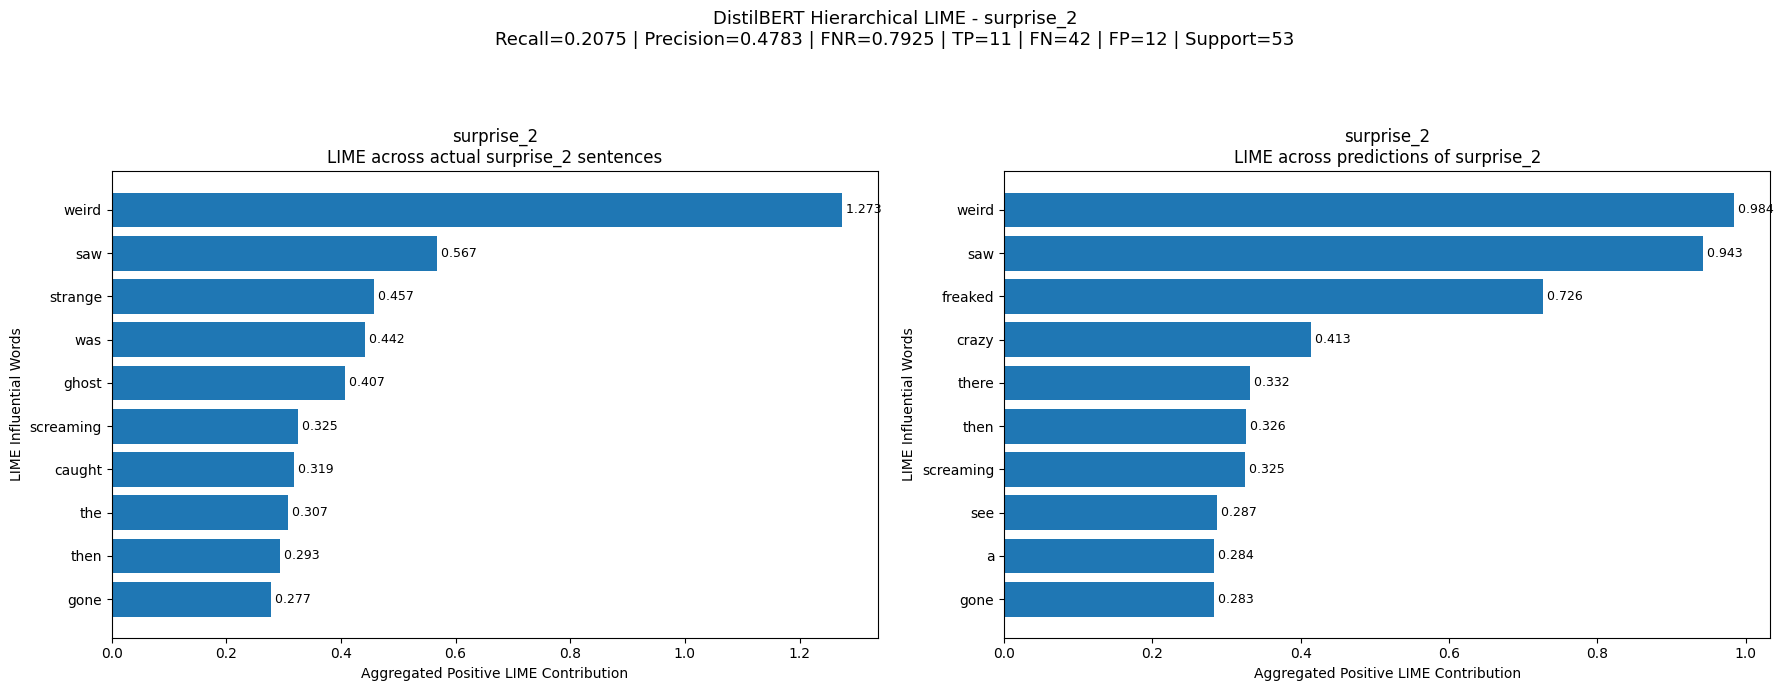

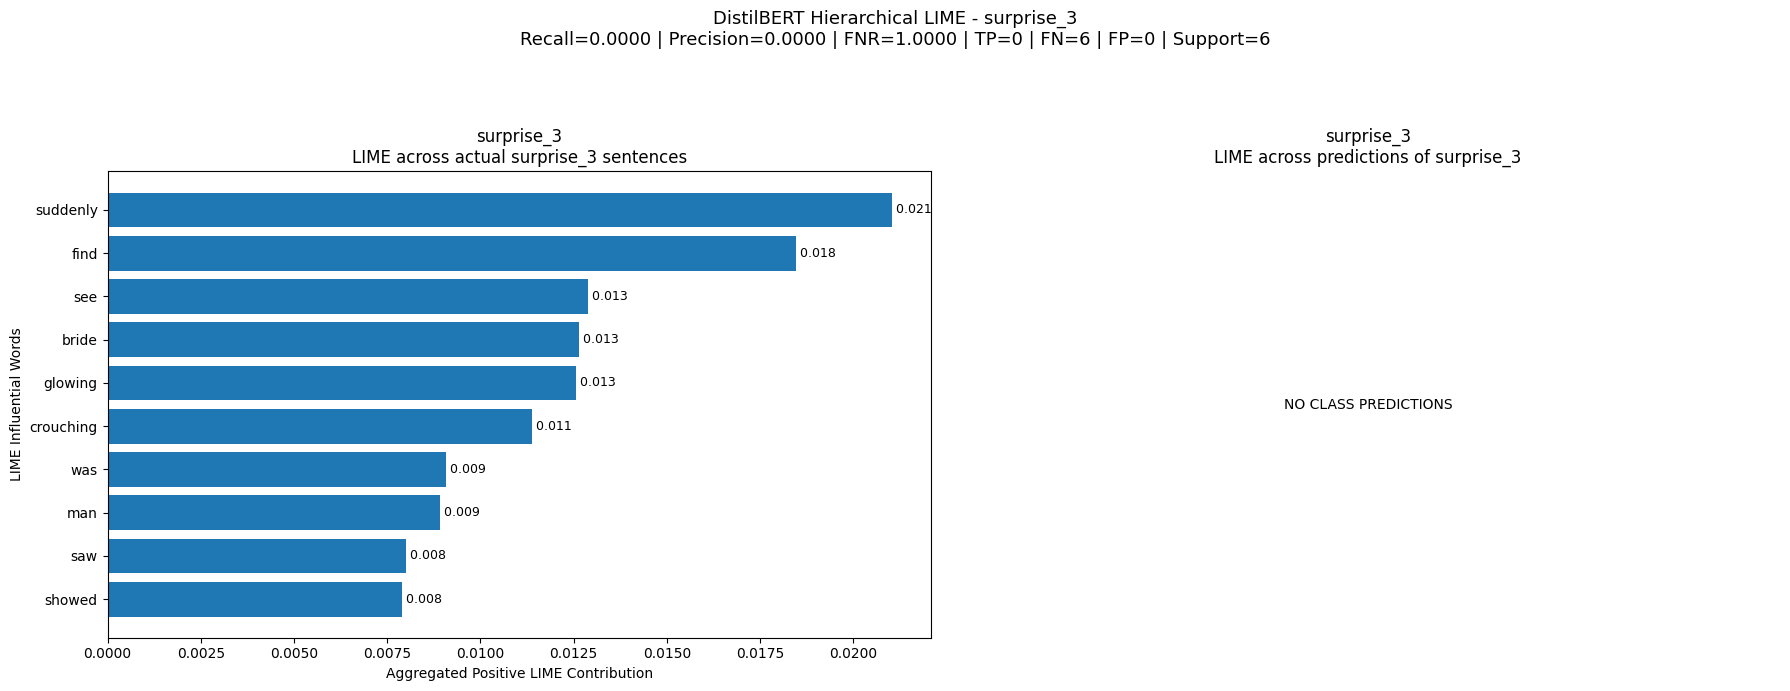


DISTILBERT HIERARCHICAL ANALYSIS COMPLETED

Step 1 log:
/content/drive/MyDrive/DistilBERT_Hierarchical_Step1.csv

Step 2 log:
/content/drive/MyDrive/DistilBERT_Hierarchical_Step2.csv

Classwise training columns:
class | precision | recall | f1_score | TP | TN | FN | FP | support

LIME CSV:
/content/drive/MyDrive/DistilBERT_Hierarchical_LIME_Results.csv

LIME columns:
class | recall | precision | fnr | TP | TN | FN | FP | support | true_class_lime_words | predicted_class_lime_words

All influential words are obtained only from LIME.
LIME uses the combined Step 1 emotion probability × Step 2 intensity probability.
Visualizations are displayed only and are not saved.


In [3]:
# =========================================================
# 27. INSTALL LIME
# =========================================================
if importlib.util.find_spec("lime") is None:
    subprocess.check_call([sys.executable,"-m","pip","install","lime","-q"])

from lime.lime_text import LimeTextExplainer

# =========================================================
# 28. LIME SETTINGS
# =========================================================
LIME_MAX_LENGTH=128
LIME_NUM_SAMPLES=1000
LIME_BATCH_SIZE=64
TOP_WORDS_VISUAL=10

step1_lime_model=trainer_step1.model.to(device)
step2_lime_model=trainer_step2.model.to(device)

step1_lime_model.eval()
step2_lime_model.eval()

# =========================================================
# 29. HIERARCHICAL LIME PROBABILITIES
# =========================================================
def hierarchical_lime_probabilities(texts):
    if isinstance(texts,str):
        texts=[texts]

    texts=list(texts)
    all_probs=[]

    for start in range(0,len(texts),LIME_BATCH_SIZE):
        batch=texts[start:start+LIME_BATCH_SIZE]

        inputs=tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=LIME_MAX_LENGTH,
            return_tensors="pt"
        )

        inputs={k:v.to(device) for k,v in inputs.items()}

        with torch.no_grad():
            step1_output=step1_lime_model(**inputs)
            probs1=torch.sigmoid(step1_output.logits)

            step2_output=step2_lime_model(**inputs)

            if isinstance(step2_output,dict):
                logits2=step2_output["logits"]
            else:
                logits2=step2_output.logits

            probs2=torch.softmax(logits2,dim=-1)

        combined=torch.zeros(
            (len(batch),len(LABELS)),
            device=device
        )

        for emotion_index,emotion in enumerate(EMOTIONS):
            for level in LEVELS:
                class_index=emotion_index*3+(level-1)

                combined[:,class_index]=(
                    probs1[:,emotion_index]*
                    probs2[:,emotion_index,level]
                )

        all_probs.append(
            combined.detach().cpu().numpy()
        )

    return np.vstack(all_probs)

# =========================================================
# 30. CLASS-SPECIFIC LIME PREDICTOR
# =========================================================
def create_hierarchical_lime_predictor(target_label):
    class_index=label2id[target_label]

    def predictor(texts):
        probs=hierarchical_lime_probabilities(texts)
        positive=probs[:,class_index]
        negative=1.0-positive

        return np.column_stack([
            negative,
            positive
        ])

    return predictor

# =========================================================
# 31. NORMALIZE LIME WORD
# =========================================================
def normalize_lime_word(word):
    word=str(word).lower().strip()
    word=re.sub(r"[^a-z0-9'_]+","",word)
    return word if word else None

# =========================================================
# 32. AGGREGATE LIME WORDS
# =========================================================
def aggregate_hierarchical_lime_words(indices,target_label,label_name):
    if len(indices)==0:
        return [],f"NO {label_name.upper()}"

    explainer=LimeTextExplainer(
        class_names=[f"NOT_{target_label}",target_label],
        split_expression=r"\W+",
        bow=True,
        random_state=SEED
    )

    predictor=create_hierarchical_lime_predictor(target_label)
    word_weights={}

    for count,test_index in enumerate(indices,start=1):
        sentence=str(test_texts_hierarchical[test_index])

        tokens=re.findall(r"\b[\w']+\b",sentence.lower())
        unique_tokens=list(dict.fromkeys(tokens))
        num_features=max(1,len(unique_tokens))

        try:
            explanation=explainer.explain_instance(
                text_instance=sentence,
                classifier_fn=predictor,
                labels=[1],
                num_features=num_features,
                num_samples=LIME_NUM_SAMPLES
            )

            lime_values=explanation.as_list(label=1)

            for word,weight in lime_values:
                if weight<=0:
                    continue

                word=normalize_lime_word(word)

                if word is None:
                    continue

                if word not in word_weights:
                    word_weights[word]=0.0

                word_weights[word]+=float(weight)

        except Exception as e:
            print(f"LIME error | {target_label} | index {test_index} | {e}")

        if count%20==0 or count==len(indices):
            print(f"{target_label} {label_name}: {count}/{len(indices)}")

    sorted_words=sorted(
        word_weights.items(),
        key=lambda x:x[1],
        reverse=True
    )

    word_string="; ".join(
        f"{word} ({weight:.4f})"
        for word,weight in sorted_words
    )

    return sorted_words,word_string

# =========================================================
# 33. TRUE + PREDICTED CLASS LIME
# =========================================================
lime_rows=[]
true_visualization_data={}
predicted_visualization_data={}

print("\n"+"="*90)
print("DISTILBERT HIERARCHICAL AGGREGATED LIME ANALYSIS")
print("="*90)

for class_number,target_label in enumerate(LABELS,start=1):
    class_index=label2id[target_label]

    true_class=true_binary_15[:,class_index]
    predicted_class=pred_binary_15[:,class_index]

    tp=int(np.sum((true_class==1)&(predicted_class==1)))
    tn=int(np.sum((true_class==0)&(predicted_class==0)))
    fn=int(np.sum((true_class==1)&(predicted_class==0)))
    fp=int(np.sum((true_class==0)&(predicted_class==1)))

    support=int(np.sum(true_class==1))

    row=final_report.get(target_label,{})
    recall=float(row.get("recall",0.0))
    precision=float(row.get("precision",0.0))
    fnr=fn/(tp+fn) if (tp+fn)>0 else 0.0

    true_indices=np.where(true_class==1)[0]
    predicted_indices=np.where(predicted_class==1)[0]

    print("\n"+"-"*70)
    print(f"[{class_number}/{len(LABELS)}] {target_label}")
    print("True class sentences:",len(true_indices))
    print("Predicted class sentences:",len(predicted_indices))

    true_words,true_word_string=aggregate_hierarchical_lime_words(
        true_indices,
        target_label,
        "true class sentences"
    )

    predicted_words,predicted_word_string=aggregate_hierarchical_lime_words(
        predicted_indices,
        target_label,
        "class predictions"
    )

    true_visualization_data[target_label]=true_words
    predicted_visualization_data[target_label]=predicted_words

    lime_rows.append({
        "class":target_label,
        "recall":round(recall,4),
        "precision":round(precision,4),
        "fnr":round(fnr,4),
        "TP":tp,
        "TN":tn,
        "FN":fn,
        "FP":fp,
        "support":support,
        "true_class_lime_words":true_word_string,
        "predicted_class_lime_words":predicted_word_string
    })

# =========================================================
# 34. SAVE LIME CSV
# =========================================================
lime_results_df=pd.DataFrame(lime_rows)

lime_results_df=lime_results_df[
    [
        "class",
        "recall",
        "precision",
        "fnr",
        "TP",
        "TN",
        "FN",
        "FP",
        "support",
        "true_class_lime_words",
        "predicted_class_lime_words"
    ]
]

lime_results_df.to_csv(
    LIME_RESULT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\n"+"="*100)
print("FINAL DISTILBERT HIERARCHICAL LIME RESULTS")
print("="*100)

display(lime_results_df)

print("\nSaved:")
print(LIME_RESULT_FILE)

# =========================================================
# 35. LIME VISUALIZATIONS
# =========================================================
for target_label in LABELS:
    true_words=true_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]
    predicted_words=predicted_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]

    fig,axes=plt.subplots(1,2,figsize=(18,7))

    if len(true_words)>0:
        names=[word for word,weight in true_words][::-1]
        values=[weight for word,weight in true_words][::-1]
        bars=axes[0].barh(names,values)

        for bar,value in zip(bars,values):
            axes[0].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[0].set_xlabel("Aggregated Positive LIME Contribution")
        axes[0].set_ylabel("LIME Influential Words")

    else:
        axes[0].text(0.5,0.5,"No true-class LIME words",ha="center",va="center")
        axes[0].axis("off")

    axes[0].set_title(
        f"{target_label}\nLIME across actual {target_label} sentences"
    )

    if len(predicted_words)>0:
        names=[word for word,weight in predicted_words][::-1]
        values=[weight for word,weight in predicted_words][::-1]
        bars=axes[1].barh(names,values)

        for bar,value in zip(bars,values):
            axes[1].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[1].set_xlabel("Aggregated Positive LIME Contribution")
        axes[1].set_ylabel("LIME Influential Words")

    else:
        axes[1].text(0.5,0.5,"NO CLASS PREDICTIONS",ha="center",va="center")
        axes[1].axis("off")

    axes[1].set_title(
        f"{target_label}\nLIME across predictions of {target_label}"
    )

    metrics=lime_results_df[
        lime_results_df["class"]==target_label
    ].iloc[0]

    fig.suptitle(
        f"DistilBERT Hierarchical LIME - {target_label}\n"
        f"Recall={metrics['recall']:.4f} | "
        f"Precision={metrics['precision']:.4f} | "
        f"FNR={metrics['fnr']:.4f} | "
        f"TP={metrics['TP']} | "
        f"FN={metrics['FN']} | "
        f"FP={metrics['FP']} | "
        f"Support={metrics['support']}",
        fontsize=13
    )

    plt.tight_layout(rect=[0,0,1,0.91])
    plt.show()
    plt.close(fig)

# =========================================================
# 36. FINISHED
# =========================================================
print("\n"+"="*100)
print("DISTILBERT HIERARCHICAL ANALYSIS COMPLETED")
print("="*100)

print("\nStep 1 log:")
print(LOG_FILE_STEP1)

print("\nStep 2 log:")
print(LOG_FILE_STEP2)

print("\nClasswise training columns:")
print("class | precision | recall | f1_score | TP | TN | FN | FP | support")

print("\nLIME CSV:")
print(LIME_RESULT_FILE)

print("\nLIME columns:")
print(
    "class | recall | precision | fnr | TP | TN | FN | FP | support | "
    "true_class_lime_words | predicted_class_lime_words"
)

print("\nAll influential words are obtained only from LIME.")
print("LIME uses the combined Step 1 emotion probability × Step 2 intensity probability.")
print("Visualizations are displayed only and are not saved.")